# Policy experiment analysis

A compact, policy-aware summary of an aggregated sequential experiment.

In [298]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / "policy_experiments").is_dir():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("Run this notebook from inside the repository")
    ROOT = ROOT.parent

# One or more aggregated result files to compare.
RESULTS = [
    ROOT / "policy_experiments" / "arc_rerun_20260818" / "staged_movingai_pogema" / "results_stitched.csv",
]
POLICY_LABELS = {
    "lacam_lns": "S1+S2 default - early stopping",
    "lacam_naive": "S1 default - early stopping ",
    "layered_v1": "learnable-fixed-params",
    "layered_variable_neighbourhood_v1": "learnable",
    "naive_budget" : "naive budget - early stopping" 
}
AUDIT_FEATURES = [
    "num_agents", "num_obstacles", "agent_density", "obstacle_density",
    "avg_shortest_path_distance", "min_shortest_path_distance",
    "max_shortest_path_distance", "cells_at_sp_ratio",
    "num_total_cells", "num_free_cells", "lower_bound_soc",
    "sp_collision_count", "sp_vertex_collision_count",
    "sp_edge_collision_count", "lacam_initial_sod", "initial_sodlb",
    "lacam_fraction_delayed_agents", "lacam_avg_delay",
    "lacam_delay_90th_percentile",
]
OUTPUT = RESULTS[0].parent
for path in RESULTS:
    if not path.exists():
        raise FileNotFoundError(f"Aggregate the experiment first: {path}")

columns = set().union(*(pd.read_csv(path, nrows=0).columns for path in RESULTS))
parameters = sorted(name for name in columns if name.startswith("parameter_"))
required = {
    "policy", "parameter_budget", "repetition", "task", "position",
    "instance_id", "solved", "budget_after", "sequence_elapsed_seconds",
    "s1_wall_seconds", "s2_wall_seconds", "s1_requested_seconds",
    "s2_requested_seconds", "s2_neighborhood_size", "s1_status", "s2_status",
    "initial_sodlb", "final_sodlb", "sodlb_improvement",
    *AUDIT_FEATURES,
}
# Full traces stay in task checkpoints; only compact decision metadata is loaded here.
usecols = required | set(parameters) | ({"s1_info", "s2_info"} & columns)
frames = []
for path in RESULTS:
    available = set(pd.read_csv(path, nrows=0).columns)
    if missing := sorted(required - available):
        raise KeyError(f"{path} is missing {missing}")
    frame = pd.read_csv(path, usecols=sorted(usecols & available))
    frame["policy"] = frame["policy"].replace(POLICY_LABELS)
    frame["_result_file"] = str(path)
    if len(RESULTS) > 1:
        frame["policy"] = path.parent.name + " · " + frame["policy"]
    frames.append(frame)
data = pd.concat(frames, ignore_index=True).sort_values(["policy", "task", "position"])
policies = data["policy"].drop_duplicates().tolist()
policy_colors = dict(zip(policies, plt.get_cmap("tab10").colors))

sequence_count = data.groupby(["policy", "task"]).ngroups
print(f"{len(data):,} instance decisions across {sequence_count} sequences")
display(data.groupby("policy").agg(
    sequences=("task", "nunique"),
    budgets=("parameter_budget", lambda values: sorted(values.unique())),
))

135,000 instance decisions across 450 sequences


,sequences,budgets
policy,,
S1 default - early stopping,90,"[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1..."
S1+S2 default - early stopping,90,"[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1..."
learnable,90,"[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1..."
learnable-fixed-params,90,"[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1..."
naive budget - early stopping,90,"[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1..."


## Sequence-level results

instances  solved_instances  \
policy                        parameter_budget                                
S1 default - early stopping   200                   300.0           31.6667   
                              400                   300.0           60.0000   
                              600                   300.0           87.0000   
                              800                   300.0          113.3333   
                              1000                  300.0          151.6667   
...                                                   ...               ...   
naive budget - early stopping 10000                 300.0          299.6667   
                              10500                 300.0          300.0000   
                              11000                 300.0          300.0000   
                              11500                 300.0          299.6667   
                              12000                 300.0          300.0000   

                                                solve_rate  solve_rate_sd  \
policy                        parameter_budget                              
S1 default - early stopping   200                   0.1056         0.0117   
                              400                   0.2000         0.0133   
                              600                   0.2900         0.0551   
                              800                   0.3778         0.0417   
                              1000                  0.5056         0.0241   
...                                                    ...            ...   
naive budget - early stopping 10000                 0.9989         0.0019   
                              10500                 1.0000         0.0000   
                              11000                 1.0000         0.0000   
                              11500                 0.9989         0.0019   
                              12000                 1.0000         0.0000   

                                                elapsed_seconds  \
policy                        parameter_budget                    
S1 default - early stopping   200                      592.8628   
                              400                      791.9338   
                              600                      996.1921   
                              800                     1195.0885   
                              1000                    1395.3470   
...                                                         ...   
naive budget - early stopping 10000                   8343.0508   
                              10500                   8810.6971   
                              11000                   9087.7047   
                              11500                   9490.6889   
                              12000                   9951.5476   

                                                charged_seconds  \
policy                        parameter_budget                    
S1 default - early stopping   200                      200.0000   
                              400                      400.0000   
                              600                      600.0000   
                              800                      800.0000   
                              1000                    1000.0000   
...                                                         ...   
naive budget - early stopping 10000                   7942.5080   
                              10500                   8409.9617   
                              11000                   8686.6696   
                              11500                   9089.8558   
                              12000                   9550.4232   

                                                remaining_seconds  \
policy                        parameter_budget                      
S1 default - early stopping   200                          0.0000   
                              400                          0.0000  

,parameter_budget,common_instances,common_instances_min,total_instances,coverage,coverage_sd
0,200,3.0000,2,300.0,0.0100,0.0058
1,400,6.6667,5,300.0,0.0222,0.0051
2,600,8.6667,7,300.0,0.0289,0.0069
3,800,14.3333,13,300.0,0.0478,0.0051
4,1000,17.0000,15,300.0,0.0567,0.0088
5,1200,20.0000,17,300.0,0.0667,0.0100
6,1400,23.0000,20,300.0,0.0767,0.0120
7,1600,27.3333,24,300.0,0.0911,0.0139
8,1800,30.6667,27,300.0,0.1022,0.0184
9,2000,34.6667,31,300.0,0.1156,0.0135


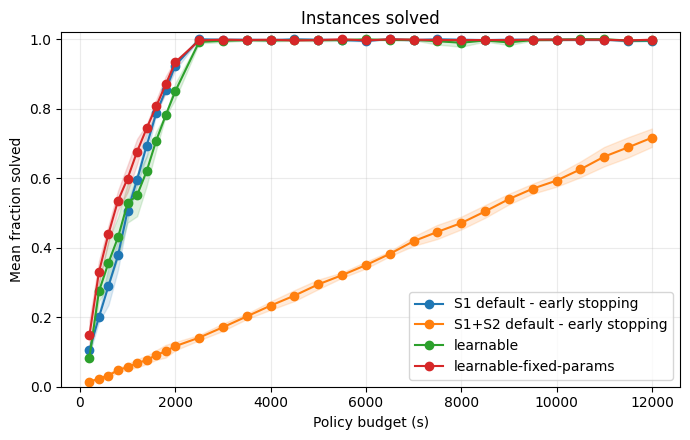

In [299]:
sequence_keys = ["policy", "parameter_budget", "repetition", "task"]
sequences = data.groupby(sequence_keys, as_index=False).agg(
    instances=("instance_id", "size"),
    solved_instances=("solved", "sum"),
    solve_rate=("solved", "mean"),
    remaining_seconds=("budget_after", "last"),
    elapsed_seconds=("sequence_elapsed_seconds", "last"),
    lacam_seconds=("s1_wall_seconds", "sum"),
    lns_seconds=("s2_wall_seconds", "sum"),
    lns_runs=("s2_wall_seconds", lambda values: values.gt(0).sum()),
    mean_initial_sodlb=("initial_sodlb", "mean"),
    mean_final_sodlb=("final_sodlb", "mean"),
    mean_improvement=("sodlb_improvement", "mean"),
)
sequences["charged_seconds"] = sequences.parameter_budget - sequences.remaining_seconds

by_run = sequences.groupby(["policy", "parameter_budget"]).agg(
    instances=("instances", "mean"),
    solved_instances=("solved_instances", "mean"),
    solve_rate=("solve_rate", "mean"),
    solve_rate_sd=("solve_rate", "std"),
    elapsed_seconds=("elapsed_seconds", "mean"),
    charged_seconds=("charged_seconds", "mean"),
    remaining_seconds=("remaining_seconds", "mean"),
    lacam_seconds=("lacam_seconds", "mean"),
    lns_seconds=("lns_seconds", "mean"),
    lns_runs=("lns_runs", "mean"),
    mean_initial_sodlb=("mean_initial_sodlb", "mean"),
    mean_final_sodlb=("mean_final_sodlb", "mean"),
    final_sodlb_sd=("mean_final_sodlb", "std"),
    mean_improvement=("mean_improvement", "mean"),
    improvement_sd=("mean_improvement", "std"),
)
display(by_run.round(4))

# Within each matched budget/repetition, retain instancs solved by every policy.
# Comparisons are paired across policies without requiring success in every repetition.
paired_parts = []
coverage_rows = []
for (budget, repetition), rows in data.groupby(["parameter_budget", "repetition"]):
    solved_sets = [
        set(run.loc[run.solved, "instance_id"])
        for _, run in rows.groupby(["policy", "task"])
    ]
    common = set.intersection(*solved_sets) if solved_sets else set()
    universe = set(rows.instance_id)
    coverage_rows.append({
        "parameter_budget": budget,
        "repetition": repetition,
        "common_instances": len(common),
        "total_instances": len(universe),
        "coverage": len(common) / len(universe) if universe else np.nan,
    })
    if common:
        paired_parts.append(rows[rows.instance_id.isin(common)])

coverage = pd.DataFrame(coverage_rows).groupby("parameter_budget", as_index=False).agg(
    common_instances=("common_instances", "mean"),
    common_instances_min=("common_instances", "min"),
    total_instances=("total_instances", "mean"),
    coverage=("coverage", "mean"),
    coverage_sd=("coverage", "std"),
).sort_values("parameter_budget")
paired_data = pd.concat(paired_parts, ignore_index=True) if paired_parts else data.iloc[:0]
paired_sequences = paired_data.groupby(sequence_keys, as_index=False).agg(
    mean_final_sodlb=("final_sodlb", "mean"),
    mean_improvement=("sodlb_improvement", "mean"),
)
paired_by_run = paired_sequences.groupby(["policy", "parameter_budget"]).agg(
    mean_final_sodlb=("mean_final_sodlb", "mean"),
    final_sodlb_sd=("mean_final_sodlb", "std"),
    mean_improvement=("mean_improvement", "mean"),
    improvement_sd=("mean_improvement", "std"),
).reset_index()
paired_by_run["mean_negative_final_sodlb"] = -paired_by_run.mean_final_sodlb

display(coverage.round(4))


def plot_band(axis, rows, mean, spread, color, label, bounds=None):
    rows = rows.sort_values("parameter_budget")
    x = rows.parameter_budget.to_numpy()
    y = rows[mean].to_numpy()
    sd = rows[spread].fillna(0).to_numpy()
    lower, upper = y - sd, y + sd
    if bounds is not None:
        lower, upper = np.clip(lower, *bounds), np.clip(upper, *bounds)
    axis.plot(x, y, marker="o", color=color, label=label)
    axis.fill_between(x, lower, upper, color=color, alpha=0.15)


fig, axis = plt.subplots(figsize=(7, 4.5))
overview_rows = by_run.reset_index()
overview_rows = overview_rows[
    ~overview_rows.policy.str.endswith(POLICY_LABELS["naive_budget"])
]
for policy, rows in overview_rows.groupby("policy"):
    plot_band(axis, rows, "solve_rate", "solve_rate_sd", policy_colors[policy], policy, (0, 1))
axis.set(title="Instances solved", xlabel="Policy budget (s)", ylabel="Mean fraction solved", ylim=(0, 1.02))
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "policy_overview.png", dpi=180)
plt.show()


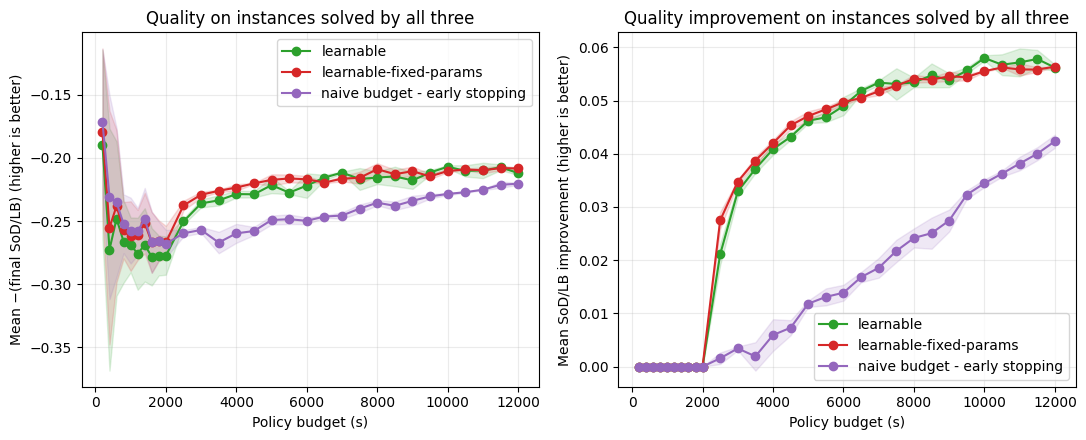

In [300]:
# Compare the two learned policies with naive_budget on exactly the same solved instances.
paired_policy_suffixes = ("learnable-fixed-params", "learnable", "naive budget - early stopping")
three_way_rows = []
three_way_coverage_rows = []

for (result_file, budget, repetition), rows in data.groupby(
    ["_result_file", "parameter_budget", "repetition"], sort=False
):
    matched = {}
    for suffix in paired_policy_suffixes:
        names = rows.loc[rows.policy.str.endswith(suffix), "policy"].unique()
        if len(names) == 1:
            matched[suffix] = rows.loc[rows.policy.eq(names[0])]
    if len(matched) != len(paired_policy_suffixes):
        continue

    solved_sets = [set(run.loc[run.solved, "instance_id"]) for run in matched.values()]
    common_instances = set.intersection(*solved_sets)
    total_instances = len(set.union(*(set(run.instance_id) for run in matched.values())))
    three_way_coverage_rows.append({
        "_result_file": result_file,
        "parameter_budget": budget,
        "repetition": repetition,
        "common_instances": len(common_instances),
        "total_instances": total_instances,
        "coverage": len(common_instances) / total_instances if total_instances else np.nan,
    })
    if not common_instances:
        continue

    for run in matched.values():
        common = run.loc[run.instance_id.isin(common_instances)]
        three_way_rows.append({
            "_result_file": result_file,
            "policy": common.policy.iloc[0],
            "parameter_budget": budget,
            "repetition": repetition,
            "common_instances": len(common_instances),
            "mean_final_sodlb": common.final_sodlb.mean(),
            "mean_improvement": common.sodlb_improvement.mean(),
        })

three_way_sequences = pd.DataFrame(three_way_rows)
if three_way_sequences.empty:
    print("No result-file/budget/repetition group contains all three requested policies with a common solved instance.")
else:
    three_way_summary = three_way_sequences.groupby(
        ["policy", "parameter_budget"], as_index=False
    ).agg(
        mean_final_sodlb=("mean_final_sodlb", "mean"),
        final_sodlb_sd=("mean_final_sodlb", "std"),
        mean_improvement=("mean_improvement", "mean"),
        improvement_sd=("mean_improvement", "std"),
    )
    three_way_summary["mean_negative_final_sodlb"] = -three_way_summary.mean_final_sodlb

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for policy, policy_rows in three_way_summary.groupby("policy"):
        color = policy_colors[policy]
        plot_band(axes[0], policy_rows, "mean_negative_final_sodlb", "final_sodlb_sd", color, policy)
        plot_band(axes[1], policy_rows, "mean_improvement", "improvement_sd", color, policy)

    axes[0].set(
        title="Quality on instances solved by all three",
        xlabel="Policy budget (s)",
        ylabel="Mean −(final SoD/LB) (higher is better)",
    )
    axes[1].set(
        title="Quality improvement on instances solved by all three",
        xlabel="Policy budget (s)",
        ylabel="Mean SoD/LB improvement (higher is better)",
    )
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT / "policy_learned_vs_naive_paired.png", dpi=180)
    plt.show()


## Time allocation by policy

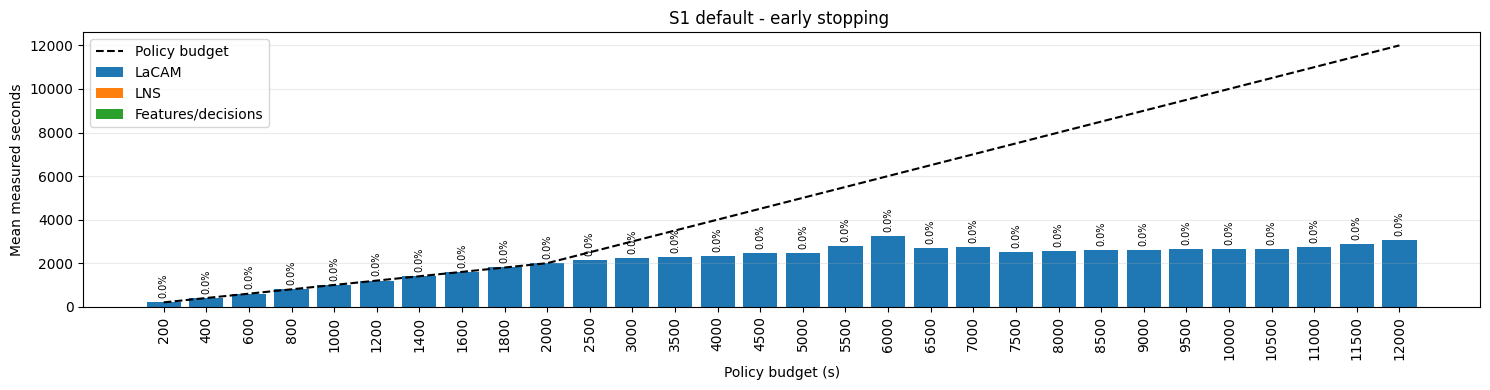

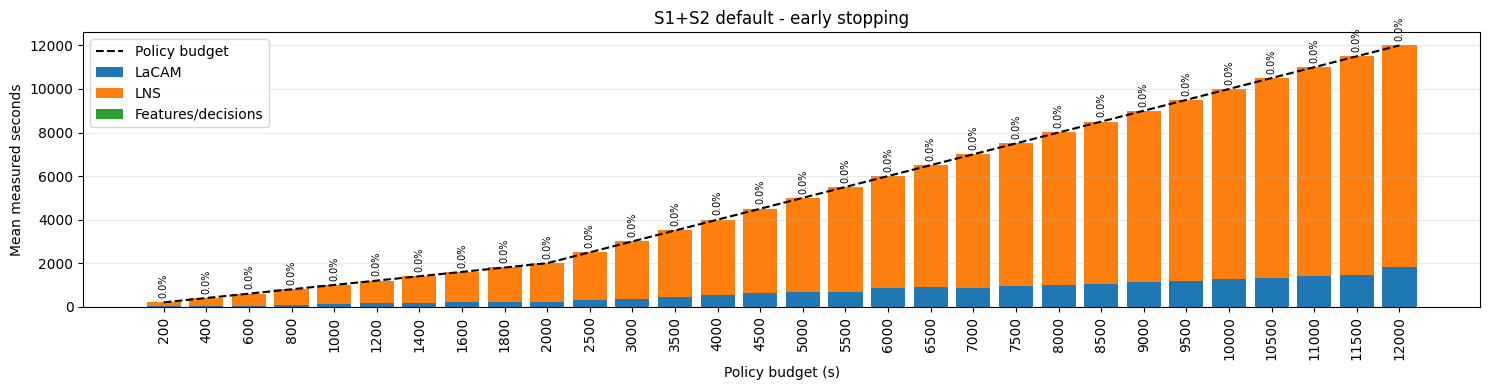

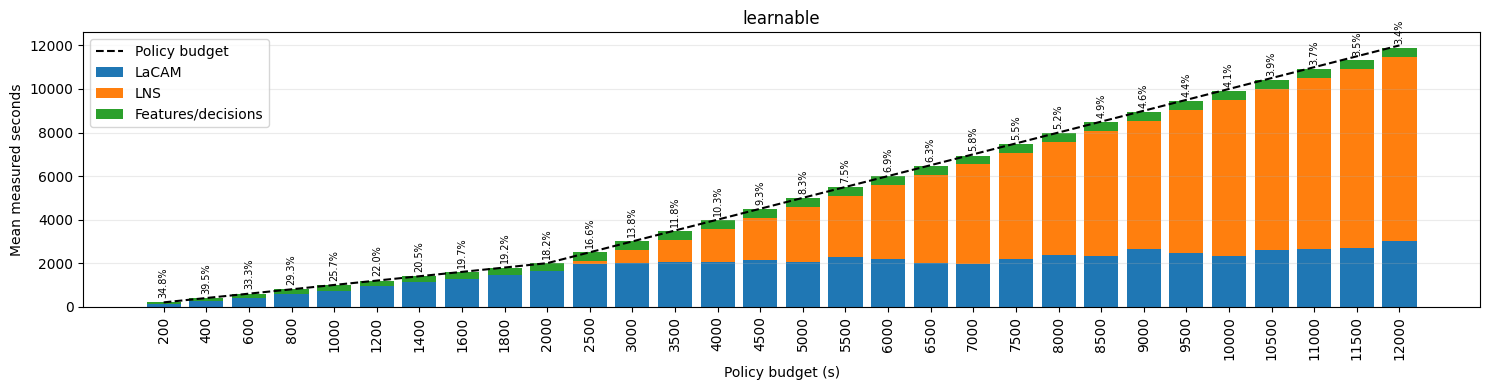

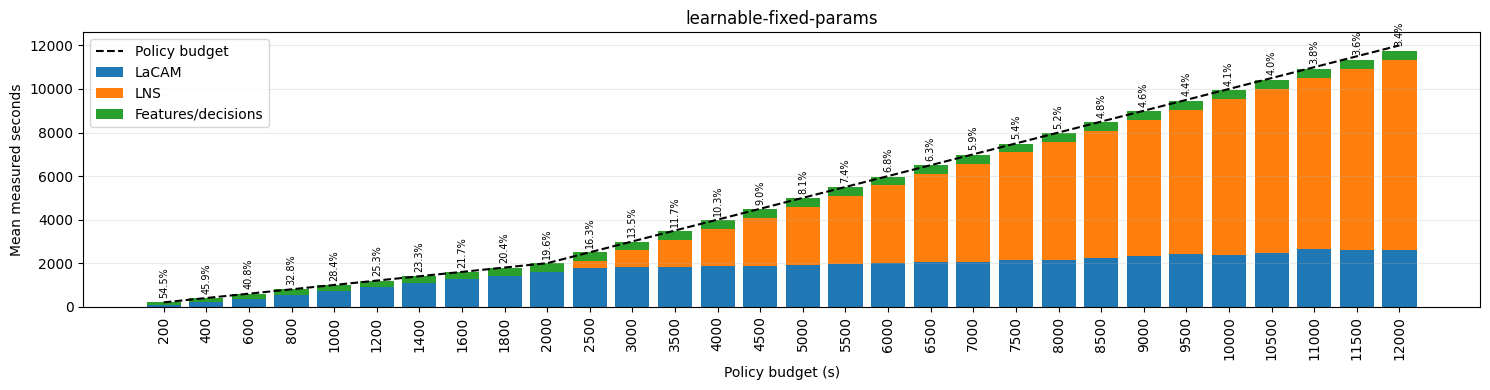

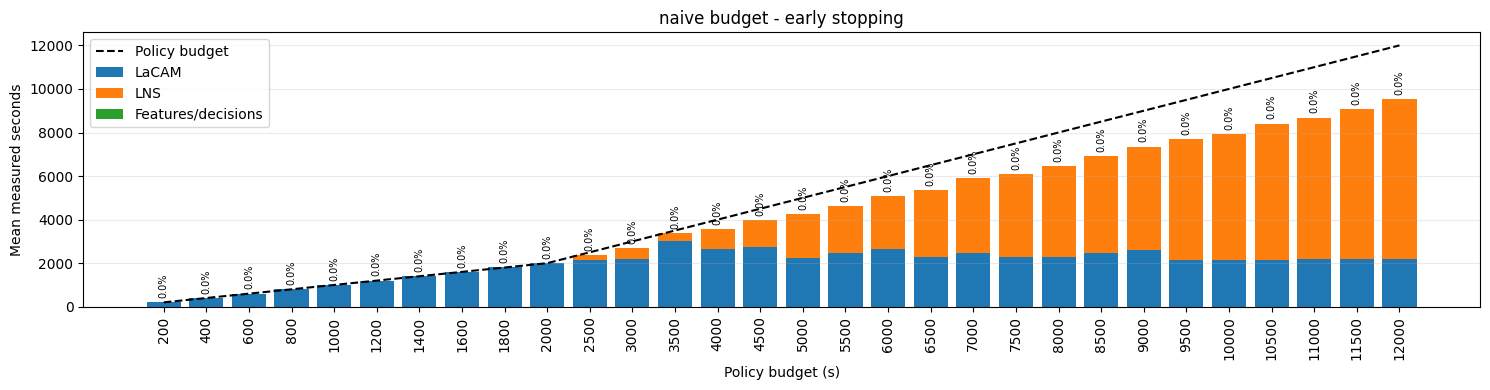

In [301]:
for policy in policies:
    fig, axis = plt.subplots(figsize=(15, 4))
    rows = by_run.loc[policy].reset_index()
    x = np.arange(len(rows))
    other = (rows.charged_seconds - rows.lacam_seconds - rows.lns_seconds).clip(lower=0)
    axis.bar(x, rows.lacam_seconds, label="LaCAM")
    axis.bar(x, rows.lns_seconds, bottom=rows.lacam_seconds, label="LNS")
    axis.bar(x, other, bottom=rows.lacam_seconds + rows.lns_seconds, label="Features/decisions")
    axis.plot(x, rows.parameter_budget, "k--", label="Policy budget")
    overhead_percent = 100 * other / rows.parameter_budget.replace(0, np.nan)
    stack_top = rows.lacam_seconds + rows.lns_seconds + other
    for position, top, percent in zip(x, stack_top, overhead_percent):
        axis.annotate(
            f"{percent:.1f}%",
            (position, top),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=7,
        )
    axis.set(
        title=f"{policy}", xlabel="Policy budget (s)", ylabel="Mean measured seconds",
        xticks=x, xticklabels=[f"{value:g}" for value in rows.parameter_budget],
    )
    axis.tick_params(axis="x", labelrotation=90)
    axis.grid(axis="y", alpha=0.25)
    axis.legend()
    fig.tight_layout()
    filename = "policy_time_allocation_" + policy.lower().replace(" ", "_").replace("+", "plus") + ".png"
    fig.savefig(OUTPUT / filename, dpi=180, bbox_inches="tight")
    plt.show()

## Individual LNS decision audit

Compare completed LNS runs with predicted improvement above 0.06. Strong examples realized more than 0.06; poor examples realized at most 0.02. Curves come from the saved task checkpoints; no solver is rerun.

At the highest available budget, the audit also ranks unique instances by their mean absolute S2 improvement-prediction error across learned-policy runs. It compares the worst 50 with the full 300-instance evaluation population using feature means, medians and standardized mean differences.

Three largest absolute S2 prediction errors


,policy,parameter_budget,repetition,task,position,instance_id,s2_neighborhood_size,s2_requested_seconds,s2_status,predicted_improvement,sodlb_improvement,prediction_error,absolute_error
17449,learnable-fixed-params,7000,2,58,49,pogema-balanced-007314-s56-d0p298-a533-seed119...,4.0,100.0,success,0.3491,0.6291,-0.2800,0.2800
18349,learnable-fixed-params,7500,2,61,49,pogema-balanced-007314-s56-d0p298-a533-seed119...,4.0,100.0,success,0.3491,0.6253,-0.2761,0.2761
15649,learnable-fixed-params,6000,2,52,49,pogema-balanced-007314-s56-d0p298-a533-seed119...,4.0,100.0,success,0.3491,0.6251,-0.2760,0.2760


Feature audit at budget 12000: 50 worst-predicted instances versus all 300 instances


,mean_absolute_error,prediction_count
instance_id,,
pogema-balanced-009267-s13-d0p276-a26-seed1873121060,0.1861,6
pogema-balanced-009929-s12-d0p222-a4-seed205199077,0.1232,6
pogema-balanced-001969-s17-d0p180-a57-seed324597451,0.1189,6
pogema-balanced-001873-s67-d0p210-a1042-seed1992876469,0.1174,6
pogema-balanced-009422-s18-d0p262-a36-seed710565226,0.1103,6
pogema-balanced-001889-s48-d0p270-a324-seed1430675411,0.1074,6
pogema-balanced-007201-s13-d0p288-a33-seed1247848645,0.1073,6
pogema-balanced-006731-s15-d0p156-a43-seed1127438442,0.0854,6
pogema-balanced-007314-s56-d0p298-a533-seed1195221700,0.0797,6


,worst 50 mean,all instances mean,worst 50 median,all instances median,standardized mean difference,absolute standardized difference
lacam_fraction_delayed_agents,0.8321,0.5930,0.8695,0.6366,0.7240,0.7240
agent_density,0.1849,0.1237,0.1871,0.1153,0.6937,0.6937
initial_sodlb,0.4621,0.2678,0.3574,0.1233,0.5202,0.5202
cells_at_sp_ratio,0.8784,0.7889,0.9002,0.8740,0.3893,0.3893
avg_shortest_path_distance,59.2496,78.7271,66.8547,74.2213,-0.3872,0.3872
num_total_cells,9585.8400,18623.5733,8556.5000,11342.5000,-0.3816,0.3816
num_free_cells,8204.6600,15523.3467,6117.0000,9680.5000,-0.3768,0.3768
obstacle_density,0.1881,0.1536,0.1992,0.1564,0.3681,0.3681
max_shortest_path_distance,151.6000,197.1000,172.5000,183.5000,-0.3558,0.3558
num_obstacles,1381.1800,3100.2267,1112.5000,1165.0000,-0.3339,0.3339


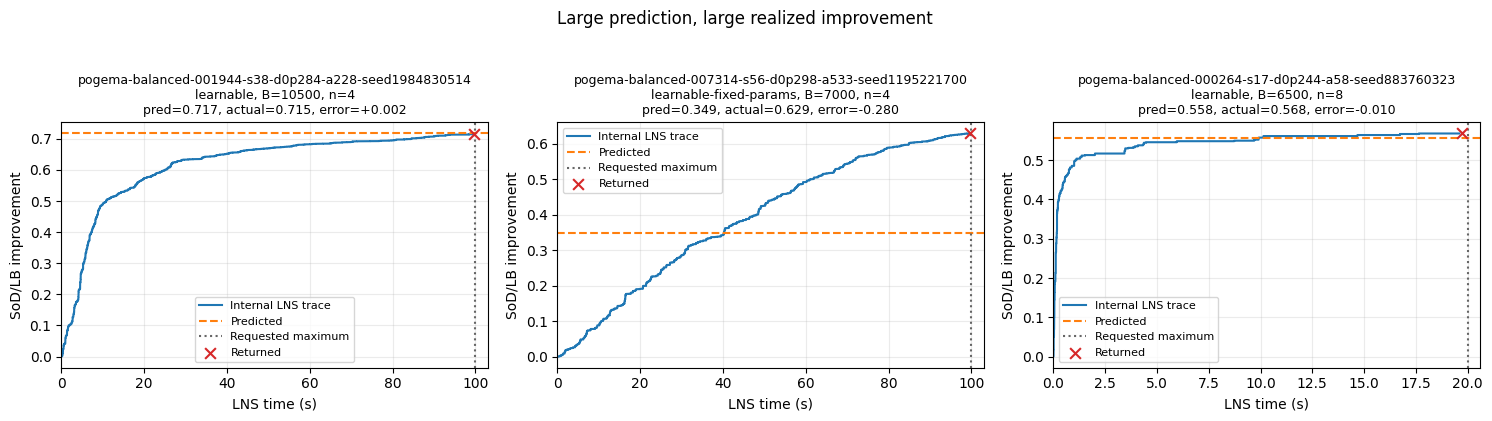

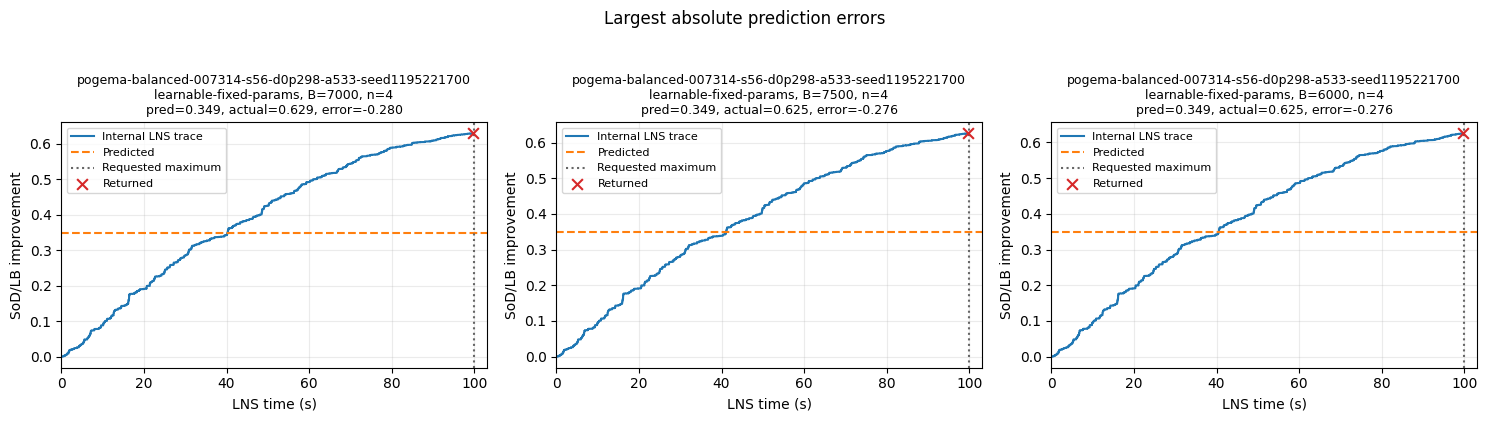

In [302]:
def predicted_improvement(value):
    try:
        return json.loads(value).get("predicted_improvement")
    except (TypeError, json.JSONDecodeError):
        return None

def checkpoint_row(row):
    path = Path(row["_result_file"]).parent / "results" / f"task_{int(row.task):06d}.json"
    return json.loads(path.read_text())["rows"][int(row.position)]

def plot_examples(examples, title, filename):
    if examples.empty:
        print(f"No examples available for {title.lower()}.")
        return
    fig, axes = plt.subplots(1, len(examples), figsize=(5 * len(examples), 4), squeeze=False)
    for axis, (_, row) in zip(axes.flat, examples.iterrows()):
        saved = checkpoint_row(row)
        trace = saved["lns_trace"]
        seconds = np.array([0, *[point["seconds"] for point in trace]])
        improvement = np.array([0, *[(saved["initial_soc"] - point["soc"]) / saved["lower_bound_soc"] for point in trace]])
        axis.step(seconds, improvement, where="post", label="Internal LNS trace")
        axis.axhline(row.predicted_improvement, color="tab:orange", linestyle="--", label="Predicted")
        axis.axvline(row.s2_requested_seconds, color="0.4", linestyle=":", label="Requested maximum")
        axis.scatter(row.s2_wall_seconds, row.sodlb_improvement, color="tab:red", marker="x", s=60, label="Returned", zorder=3)
        map_name = row.instance_id.split("-random-")[0]
        axis.set_title(
            f"{map_name}\n{row.policy}, B={row.parameter_budget:g}, n={row.s2_neighborhood_size:g}\n"
            f"pred={row.predicted_improvement:.3f}, actual={row.sodlb_improvement:.3f}, "
            f"error={row.predicted_improvement - row.sodlb_improvement:+.3f}",
            fontsize=9,
        )
        axis.set(xlabel="LNS time (s)", ylabel="SoD/LB improvement", xlim=(0, max(seconds[-1], row.s2_wall_seconds, row.s2_requested_seconds) * 1.03))
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
    fig.suptitle(title, y=1.04)
    fig.tight_layout()
    fig.savefig(OUTPUT / filename, dpi=180, bbox_inches="tight")
    plt.show()

audit = data[data.s2_wall_seconds.gt(0) & data.solved].copy()
audit["predicted_improvement"] = audit.s2_info.map(predicted_improvement)
audit = audit.dropna(subset=["predicted_improvement", "sodlb_improvement"])
large = audit[audit.s2_status.eq("success") & audit.predicted_improvement.gt(0.06)]
strong = large[large.sodlb_improvement.gt(0.06)].sort_values("sodlb_improvement", ascending=False).drop_duplicates("instance_id").head(3)
audit["prediction_error"] = audit.predicted_improvement - audit.sodlb_improvement
audit["absolute_error"] = audit.prediction_error.abs()
worst = audit.nlargest(3, "absolute_error")
print("Three largest absolute S2 prediction errors")
display(worst[[
    "policy", "parameter_budget", "repetition", "task", "position",
    "instance_id", "s2_neighborhood_size", "s2_requested_seconds",
    "s2_status", "predicted_improvement", "sodlb_improvement",
    "prediction_error", "absolute_error",
]].round(4))

highest_budget = audit.parameter_budget.max()
learned_at_highest_budget = data[
    data.parameter_budget.eq(highest_budget)
    & data.policy.str.endswith(("learnable-fixed-params", "learnable"))
].copy()
all_instance_features = learned_at_highest_budget.groupby("instance_id")[AUDIT_FEATURES].mean()
high_budget_errors = audit[audit.parameter_budget.eq(highest_budget)]
instance_errors = high_budget_errors.groupby("instance_id").absolute_error.agg(
    mean_absolute_error="mean",
    prediction_count="size",
).sort_values("mean_absolute_error", ascending=False)
worst_50_instances = instance_errors.head(50)
worst_50_features = all_instance_features.loc[
    all_instance_features.index.intersection(worst_50_instances.index)
]
population_std = all_instance_features.std(ddof=1).replace(0, np.nan)
feature_comparison = pd.DataFrame({
    "worst 50 mean": worst_50_features.mean(),
    "all instances mean": all_instance_features.mean(),
    "worst 50 median": worst_50_features.median(),
    "all instances median": all_instance_features.median(),
})
feature_comparison["standardized mean difference"] = (
    feature_comparison["worst 50 mean"]
    - feature_comparison["all instances mean"]
) / population_std
feature_comparison["absolute standardized difference"] = feature_comparison[
    "standardized mean difference"
].abs()
feature_comparison = feature_comparison.sort_values(
    "absolute standardized difference", ascending=False
)
print(
    f"Feature audit at budget {highest_budget:g}: "
    f"{len(worst_50_features)} worst-predicted instances versus "
    f"all {len(all_instance_features)} instances"
)
display(worst_50_instances.round(4))
display(feature_comparison.round(4))

plot_examples(strong, "Large prediction, large realized improvement", "decision_audit_strong.png")
plot_examples(worst, "Largest absolute prediction errors", "decision_audit_worst.png")

## Expected versus realized S2 gain

Projected gain is the selected model's predicted SoD/LB improvement. Totals and selection counts are averaged across repeated sequences; horizon 0 denotes skipping S2.

,policy,parameter_budget,s2_selections,projected_total,actual_total
0,learnable,200,0.0000,0.0000,0.0000
1,learnable,400,0.0000,0.0000,0.0000
2,learnable,600,0.0000,0.0000,0.0000
3,learnable,800,0.0000,0.0000,0.0000
4,learnable,1000,0.0000,0.0000,0.0000
5,learnable,1200,0.0000,0.0000,0.0000
6,learnable,1400,0.0000,0.0000,0.0000
7,learnable,1600,0.0000,0.0000,0.0000
8,learnable,1800,0.0000,0.0000,0.0000
9,learnable,2000,0.0000,0.0000,0.0000


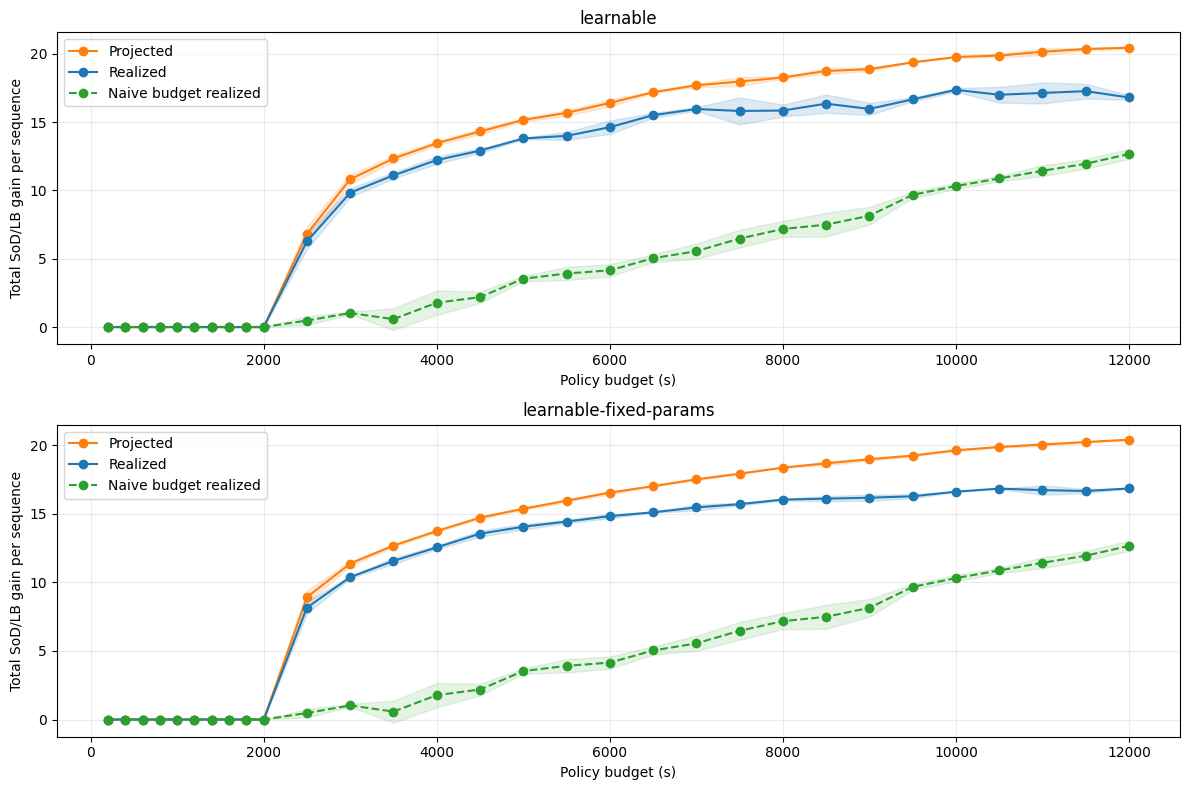

realized gain below prediction (%),learnable,learnable-fixed-params
budget (s),,
200,NaN,NaN
400,NaN,NaN
600,NaN,NaN
800,NaN,NaN
1000,NaN,NaN
1200,NaN,NaN
1400,NaN,NaN
1600,NaN,NaN
1800,NaN,NaN


learnable


selections  projected_total  \
parameter_budget horizon neighbourhood                                
200              0       skip              25.0000           0.0000   
400              0       skip              82.3333           0.0000   
600              0       skip             107.0000           0.0000   
800              0       skip             129.0000           0.0000   
1000             0       skip             158.3333           0.0000   
...                                            ...              ...   
12000            50      n8                15.6667           1.5825   
                 100     n16                0.6667           0.0858   
                         n32                0.3333           0.0068   
                         n4                45.3333           7.4048   
                         n8                11.3333           1.6966   

                                        actual_total  projected_per_selection  \
parameter_budget horizon neighbourhood                                          
200              0       skip                 0.0000                   0.0000   
400              0       skip                 0.0000                   0.0000   
600              0       skip                 0.0000                   0.0000   
800              0       skip                 0.0000                   0.0000   
1000             0       skip                 0.0000                   0.0000   
...                                              ...                      ...   
12000            50      n8                   1.2947                   0.1010   
                 100     n16                  0.0823                   0.1287   
                         n32                  0.0064                   0.0203   
                         n4                   6.1470                   0.1633   
                         n8                   1.4073                   0.1497   

                                        actual_per_selection  
parameter_budget horizon neighbourhood                        
200              0       skip                         0.0000  
400              0       skip                         0.0000  
600              0       skip                         0.0000  
800              0       skip                         0.0000  
1000             0       skip                         0.0000  
...                                                      ...  
12000            50      n8                           0.0826  
                 100     n16                          0.1235  
                         n32                          0.0192  
                         n4                           0.1356  
                         n8                           0.1242  

[441 rows x 5 columns]

learnable-fixed-params


selections  projected_total  \
parameter_budget horizon neighbourhood                                
200              0       skip              44.3333           0.0000   
400              0       skip              99.0000           0.0000   
600              0       skip             132.0000           0.0000   
800              0       skip             160.6667           0.0000   
1000             0       skip             179.6667           0.0000   
...                                            ...              ...   
12000            10      n4                20.3333           0.6990   
                 20      n4                26.6667           1.6563   
                 30      n4                 8.0000           0.7435   
                 50      n4                28.6667           2.3890   
                 100     n4                61.0000           9.5992   

                                        actual_total  projected_per_selection  \
parameter_budget horizon neighbourhood                                          
200              0       skip                 0.0000                   0.0000   
400              0       skip                 0.0000                   0.0000   
600              0       skip                 0.0000                   0.0000   
800              0       skip                 0.0000                   0.0000   
1000             0       skip                 0.0000                   0.0000   
...                                              ...                      ...   
12000            10      n4                   0.6211                   0.0344   
                 20      n4                   1.3116                   0.0621   
                 30      n4                   0.7110                   0.0929   
                 50      n4                   1.8222                   0.0833   
                 100     n4                   8.2307                   0.1574   

                                        actual_per_selection  
parameter_budget horizon neighbourhood                        
200              0       skip                         0.0000  
400              0       skip                         0.0000  
600              0       skip                         0.0000  
800              0       skip                         0.0000  
1000             0       skip                         0.0000  
...                                                      ...  
12000            10      n4                           0.0305  
                 20      n4                           0.0492  
                 30      n4                           0.0889  
                 50      n4                           0.0636  
                 100     n4                           0.1349  

[188 rows x 5 columns]

In [303]:
learned = data.policy.str.endswith(("learnable-fixed-params", "learnable"))
decisions = data[learned & data.initial_sodlb.notna()].copy()

def parse_info(value):
    if not isinstance(value, str) or not value.strip():
        return {}
    try:
        return json.loads(value)
    except json.JSONDecodeError:
        return {}

info = decisions.s2_info.map(parse_info)
selected = decisions.s2_requested_seconds.gt(0)
decisions["horizon"] = decisions.s2_requested_seconds.where(selected, 0).astype(int)
decisions["neighbourhood"] = np.where(
    selected,
    "n" + decisions.s2_neighborhood_size.fillna(0).astype(int).astype(str),
    "skip",
)
decisions["projected_gain"] = [float(item.get("predicted_improvement", 0.0)) for item in info]
decisions["actual_gain"] = decisions.sodlb_improvement.fillna(0.0)

sequence_gain = decisions.groupby(
    ["policy", "parameter_budget", "repetition", "task"], as_index=False
).agg(
    projected_gain=("projected_gain", "sum"),
    actual_gain=("actual_gain", "sum"),
    s2_selections=("horizon", lambda values: values.gt(0).sum()),
)
gain_summary = sequence_gain.groupby(["policy", "parameter_budget"]).agg(
    projected_total=("projected_gain", "mean"),
    projected_sd=("projected_gain", "std"),
    actual_total=("actual_gain", "mean"),
    actual_sd=("actual_gain", "std"),
    s2_selections=("s2_selections", "mean"),
).reset_index()

naive = data[
    data.policy.str.endswith(POLICY_LABELS["naive_budget"])
    & data.initial_sodlb.notna()
].copy()
naive["actual_gain"] = naive.sodlb_improvement.fillna(0.0)
naive_sequence = naive.groupby(
    ["_result_file", "parameter_budget", "repetition", "task"], as_index=False
).agg(actual_gain=("actual_gain", "sum"))
naive_summary = naive_sequence.groupby(
    ["_result_file", "parameter_budget"], as_index=False
).agg(actual_total=("actual_gain", "mean"), actual_sd=("actual_gain", "std"))
policy_source = decisions.groupby("policy")["_result_file"].first()
display(gain_summary[[
    "policy", "parameter_budget", "s2_selections",
    "projected_total", "actual_total",
]].round(4))

fig, axes = plt.subplots(len(gain_summary.policy.unique()), 1, figsize=(12, 4 * len(gain_summary.policy.unique())), squeeze=False)
for axis, (policy, rows) in zip(axes.flat, gain_summary.groupby("policy", sort=False)):
    rows = rows.sort_values("parameter_budget")
    x = rows.parameter_budget.to_numpy()
    for mean, spread, label, color in [
        ("projected_total", "projected_sd", "Projected", "tab:orange"),
        ("actual_total", "actual_sd", "Realized", "tab:blue"),
    ]:
        y = rows[mean].to_numpy()
        sd = rows[spread].fillna(0).to_numpy()
        axis.plot(x, y, marker="o", color=color, label=label)
        axis.fill_between(x, y - sd, y + sd, color=color, alpha=0.15)
    baseline = naive_summary[naive_summary._result_file.eq(policy_source[policy])].sort_values("parameter_budget")
    if not baseline.empty:
        bx = baseline.parameter_budget.to_numpy()
        by = baseline.actual_total.to_numpy()
        bsd = baseline.actual_sd.fillna(0).to_numpy()
        axis.plot(bx, by, marker="o", linestyle="--", color="tab:green", label="Naive budget realized")
        axis.fill_between(bx, by - bsd, by + bsd, color="tab:green", alpha=0.12)
    axis.set(title=policy, xlabel="Policy budget (s)", ylabel="Total SoD/LB gain per sequence")
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "s2_expected_vs_realized.png", dpi=180, bbox_inches="tight")
plt.show()

gain_summary["realized_shortfall_pct"] = 100 * (
    gain_summary.projected_total - gain_summary.actual_total
) / gain_summary.projected_total.replace(0, np.nan)
shortfall_table = gain_summary.pivot(
    index="parameter_budget",
    columns="policy",
    values="realized_shortfall_pct",
).round(1)
shortfall_table.index.name = "budget (s)"
shortfall_table.columns.name = "realized gain below prediction (%)"
display(shortfall_table)

sequence_counts = decisions[["policy", "parameter_budget", "repetition", "task"]].drop_duplicates().groupby(
    ["policy", "parameter_budget"]
).size().rename("sequences")
action_summary = decisions.groupby(
    ["policy", "parameter_budget", "horizon", "neighbourhood"], as_index=False
).agg(
    selections=("horizon", "size"),
    projected_total=("projected_gain", "sum"),
    actual_total=("actual_gain", "sum"),
)
action_summary = action_summary.join(sequence_counts, on=["policy", "parameter_budget"])
action_summary["projected_per_selection"] = action_summary.projected_total / action_summary.selections
action_summary["actual_per_selection"] = action_summary.actual_total / action_summary.selections
action_summary[["selections", "projected_total", "actual_total"]] = action_summary[[
    "selections", "projected_total", "actual_total"
]].div(action_summary.sequences, axis=0)
action_summary = action_summary.drop(columns="sequences")
for policy, rows in action_summary.groupby("policy", sort=False):
    print(policy)
    display(rows.drop(columns="policy").round(4).set_index(["parameter_budget", "horizon", "neighbourhood"]))


## Policy scores

Scores are averaged over repetitions; final SoD/LB is averaged over solved instances, while quality improvement is summed within each sequence and divided by all instances in that sequence.

In [304]:
sequence_scores = (
    data.groupby(
        ["policy", "parameter_budget", "repetition", "task"],
        as_index=False,
    ).agg(
        instances=("instance_id", "size"),
        solved_instances=("solved", "sum"),
        mean_final_sodlb=("final_sodlb", "mean"),
        total_sodlb_improvement=("sodlb_improvement", "sum"),
    )
)
sequence_scores["mean_sodlb_improvement"] = (
    sequence_scores.total_sodlb_improvement / sequence_scores.instances
)
scores = (
    sequence_scores.groupby(["parameter_budget", "policy"], as_index=False)
    .agg(
        solved_instances=("solved_instances", "mean"),
        mean_final_sodlb=("mean_final_sodlb", "mean"),
        mean_sodlb_improvement=("mean_sodlb_improvement", "mean"),
    )
)
scores["score"] = [
    (round(solved, 1), round(quality, 4), round(improvement, 4))
    for solved, quality, improvement in zip(
        scores.solved_instances,
        scores.mean_final_sodlb,
        scores.mean_sodlb_improvement,
    )
]
score_table = scores.pivot(
    index="parameter_budget",
    columns="policy",
    values="score",
).sort_index(axis=1)
score_table.index.name = "budget (s)"
score_table.columns.name = (
    "policy: (solved instances, mean final SoD/LB, "
    "mean SoD/LB improvement per instance)"
)
display(score_table)


"policy: (solved instances, mean final SoD/LB, mean SoD/LB improvement per instance)",S1 default - early stopping,S1+S2 default - early stopping,learnable,learnable-fixed-params,naive budget - early stopping
budget (s),,,,,
200,"(31.7, 0.3093, 0.0)","(4.3, 0.1014, 0.0008)","(25.0, 0.1866, 0.0)","(44.3, 0.221, 0.0)","(31.7, 0.3089, 0.0)"
400,"(60.0, 0.3004, 0.0)","(7.0, 0.1264, 0.0015)","(82.3, 0.247, 0.0)","(99.0, 0.2296, 0.0)","(60.3, 0.2995, 0.0)"
600,"(87.0, 0.2986, 0.0)","(9.7, 0.155, 0.0022)","(107.0, 0.2313, 0.0)","(132.0, 0.2177, 0.0)","(87.3, 0.3002, 0.0)"
800,"(113.3, 0.2852, 0.0)","(14.3, 0.181, 0.0037)","(129.0, 0.2475, 0.0)","(160.7, 0.2362, 0.0)","(118.7, 0.2927, 0.0)"
1000,"(151.7, 0.272, 0.0)","(17.0, 0.1915, 0.0041)","(158.3, 0.2578, 0.0)","(179.7, 0.2468, 0.0)","(153.3, 0.2735, 0.0)"
1200,"(178.7, 0.2705, 0.0)","(20.3, 0.174, 0.0047)","(165.3, 0.2674, 0.0)","(203.0, 0.2489, 0.0)","(178.3, 0.2698, 0.0)"
1400,"(208.0, 0.2688, 0.0)","(23.0, 0.1782, 0.0054)","(186.0, 0.2673, 0.0)","(223.0, 0.2494, 0.0)","(207.0, 0.2684, 0.0)"
1600,"(236.0, 0.2649, 0.0)","(27.3, 0.1792, 0.0061)","(212.3, 0.2613, 0.0)","(242.0, 0.258, 0.0)","(178.0, 0.2741, 0.0)"
1800,"(256.0, 0.265, 0.0)","(30.7, 0.1875, 0.0069)","(234.3, 0.2608, 0.0)","(261.0, 0.267, 0.0)","(201.7, 0.2721, 0.0)"
